script for loading the data from created data sets

# Importing packeges 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import numpy as np
import json

from pathlib import Path

import matplotlib.pyplot as plt

hbar = 1.054571817 * 1e-34
eV = 1.6 * 1e-19
ps = 1e-12

# Loading and plotting data functions 

## loading fun

In [4]:
def load_trajectory(filename):

    data = np.load(filename)

    taus = {
        "tau_relax1": float(data["tau_relax1"]),
        "tau_relax2": float(data["tau_relax2"]),
        "tau_deph1": float(data["tau_deph1"]),
        "tau_deph2": float(data["tau_deph2"]),
        "tau_cordeph": float(data["tau_cordeph"])
    }

    return {"psi0": data["psi0"], "taus": taus, "times": data["times"], "rhos": data["rhos"]}

## plotting fun

In [6]:
# plotting signals (as many as wanted on one plot)
def plot_signals(signals, t_axis = None, labels=None, points=None, pointlabels=None):
    fig, ax = plt.subplots()
    for s, sig in enumerate(signals):
        if t_axis is None:
            t_axis = np.linspace(0.,1., num=len(sig), endpoint=True)
        ax.plot(t_axis, sig, label=labels[s])
    if points is not None:
        for p, pts in enumerate(points):
            ax.scatter(pts[0], pts[1], marker='x', label=pointlabels[p])
    if labels is not None or pointlabels is not None: ax.legend()
    plt.show()

## others 

In [8]:
from pathlib import Path
import numpy as np


def plot_trajectory(dataset_dir, trajectory_number):

    filename = (
        Path(dataset_dir)
        / f"traj_{trajectory_number:06d}.npz"
    )

    traj = load_trajectory(filename)

    rhos_np = traj["rhos"]
    times = traj["times"]

    # Safety check in case batch dimension survived

    if rhos_np.ndim == 4:
        rhos_np = rhos_np.squeeze(1)

    # populations

    pop_00 = rhos_np[:, 0, 0].real
    pop_01 = rhos_np[:, 1, 1].real
    pop_10 = rhos_np[:, 2, 2].real
    pop_11 = rhos_np[:, 3, 3].real

    # coherences

    coh_00_11 = np.abs(rhos_np[:, 0, 3])

    coh_00_01 = np.abs(rhos_np[:, 0, 1])

    coh_11_01 = np.abs(rhos_np[:, 3, 1])

    coh_10_01 = np.abs(rhos_np[:, 2, 1])

    # populations plot

    plot_signals(
        [pop_00, pop_01, pop_10, pop_11],

        labels=[
            r'$|00\rangle$',
            r'$|01\rangle$',
            r'$|10\rangle$',
            r'$|11\rangle$'
        ],

        t_axis=times/ps
    )

    # coherences plot

    plot_signals(
        [
            coh_00_11,
            coh_00_01,
            coh_11_01,
            coh_10_01
        ],

        labels=[
            r'$|00\rangle\langle11|$',
            r'$|00\rangle\langle01|$',
            r'$|11\rangle\langle01|$',
            r'$|10\rangle\langle01|$'
        ],

        t_axis=times/ps
    )

    return traj

In [10]:
from pathlib import Path


def list_trajectories(dataset_dir):

    files = sorted(
        Path(dataset_dir).glob("traj_*.npz")
    )

    print(
        f"Found {len(files)} trajectories"
    )

    for f in files[:10]:
        print(f.name)

    if len(files) > 10:
        print("...")

In [15]:
def inspect_trajectory(
        dataset_dir,
        trajectory_number):

    filename = (
        Path(dataset_dir)
        / f"traj_{trajectory_number:06d}.npz"
    )

    traj = load_trajectory(filename)

    print("Initial state:")
    print(traj["psi0"])

    print()

    print("Parameters:")

    for key, value in traj["taus"].items():
        print(f"{key}: {value}")

    print()

    print("Number of time steps:")
    print(len(traj["times"]))

    print()

    print("Density matrix shape:")
    print(traj["rhos"].shape)

# Implementation

In [18]:
list_trajectories("dataset_test_3_20ps_narrow_5000t")

Found 5000 trajectories
traj_000000.npz
traj_000001.npz
traj_000002.npz
traj_000003.npz
traj_000004.npz
traj_000005.npz
traj_000006.npz
traj_000007.npz
traj_000008.npz
traj_000009.npz
...


In [20]:
inspect_trajectory(
    "dataset_test_3_20ps_narrow_5000t",
    1
)

Initial state:
[ 0.68386831+0.j  0.01316276+0.j -0.03557987+0.j  0.72861852+0.j]

Parameters:
tau_relax1: 2.3817989578186205e-11
tau_relax2: 1.799631575983605e-11
tau_deph1: 1.856423454987765e-11
tau_deph2: 2.0027945531761397e-11
tau_cordeph: 1.8732679608359043e-11

Number of time steps:
401

Density matrix shape:
(401, 4, 4)


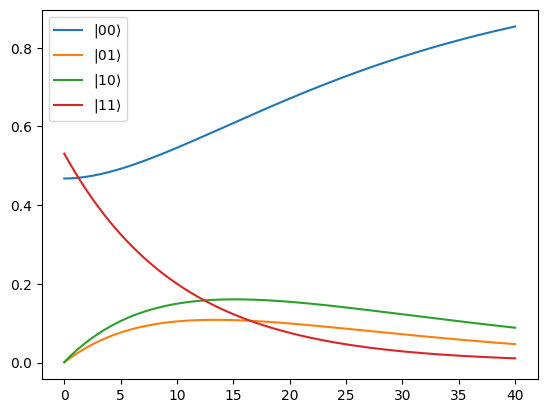

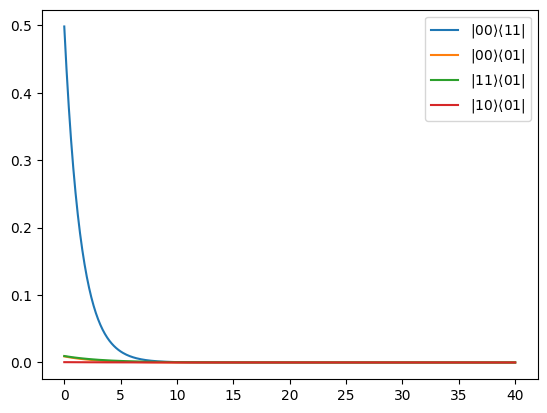

In [22]:
traj = plot_trajectory(
    "dataset_test_3_20ps_narrow_5000t",
    1
)